## Ensemble Detection: Isolation Forest + XGBoost

The following section combines the unsupervised Isolation Forest with the supervised XGBoost model 
to create a two-stage detection pipeline. This represents a more production-realistic approach to 
network intrusion detection than either model alone.

### How it works

1. **Isolation Forest** screens all incoming traffic — flagging anything that deviates significantly 
   from learned normal behaviour as anomalous
2. **XGBoost** classifies the flagged traffic — identifying the specific attack type from the 15 
   known categories

Traffic that Isolation Forest considers normal passes through without XGBoost classification. 
Traffic flagged as anomalous is passed to XGBoost for a specific label.

### Why this combination works

- Isolation Forest catches **novel attacks** that XGBoost has never seen
- XGBoost provides **specific classification** of known attack types, reducing false alarms from 
  Isolation Forest
- Together they provide both breadth (unknown threats) and precision (known threat classification)

This ensemble approach is a differentiating feature of this project and reflects realistic 
production architecture in network security systems.

In [27]:
import joblib
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns

# Load the preprocessed data from .npy files
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')


# Load models and encoders
network_dataset_encoder = joblib.load('../models/label_encoder.pkl')
network_dataset_iforest = joblib.load('../models/network_dataset_iforest.pkl')
network_dataset_xgb = joblib.load('../models/network_dataset_xgb.pkl')
contamination = joblib.load('../models/iforest_contamination.pkl')  # Load the contamination value

/opt/anaconda3/envs/anomaly-detector/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [28]:
# Ensemble the models using a Rule based if-else statement
class EnsembleModel:
    def __init__(self, iforest, xgb):
        self.iforest = iforest
        self.xgb = xgb
    
    def predict(self, X):
        y_pred_iforest = self.iforest.predict(X)
        y_pred_iforest = np.where(y_pred_iforest == -1, 1, 0)
        anomaly_flagged = y_pred_iforest == 1
        final_predictions = np.zeros(len(X), dtype=int)
        final_predictions[anomaly_flagged] = self.xgb.predict(X[anomaly_flagged])
        return final_predictions

# Instantiate and use the ensemble model
network_dataset_ensemble = EnsembleModel(network_dataset_iforest, network_dataset_xgb)
final_predictions = network_dataset_ensemble.predict(X_test)
         

    


In [29]:
#Evaluate the ensemble model
print("Classification Report for Ensemble Model:")
print(classification_report(y_test, final_predictions, zero_division=0, target_names=network_dataset_encoder.classes_))
f1_score_macro_ensemble = f1_score(y_test, final_predictions, average='macro', zero_division=0)
precision_score_ensemble = precision_score(y_test, final_predictions, average='macro', zero_division=0)
recall_score_ensemble = recall_score(y_test, final_predictions, average='macro', zero_division=0)
print(f"Ensemble Model - F1 macro Score: {f1_score_macro_ensemble:.4f}, Precision: {precision_score_ensemble:.4f}, Recall: {recall_score_ensemble:.4f}") 

with open('../reports/classification_report_ensemble.txt', 'w') as f:
    f.write(classification_report(y_test, final_predictions, zero_division=0, target_names=network_dataset_encoder.classes_))

Classification Report for Ensemble Model:
                            precision    recall  f1-score   support

                    BENIGN       0.93      1.00      0.96    419012
                       Bot       1.00      0.05      0.10       390
                      DDoS       1.00      0.64      0.78     25603
             DoS GoldenEye       1.00      0.92      0.96      2057
                  DoS Hulk       1.00      0.90      0.95     34569
          DoS Slowhttptest       0.99      0.92      0.95      1046
             DoS slowloris       1.00      0.64      0.78      1077
               FTP-Patator       1.00      0.00      0.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      1.00      1.00         7
                  PortScan       1.00      0.01      0.03     18139
               SSH-Patator       0.00      0.00      0.00       644
  Web Attack - Brute Force       0.93      0.04      0.08       294
Web A

#### Ensemble — Results & Interpretation

The ensemble achieves a macro F1 of 0.51 compared to XGBoost's 0.9036 standalone. 
This reduction is expected — Isolation Forest has a malicious recall of 0.60, 
meaning 40% of attacks never reach XGBoost and default to BENIGN.

Per-class analysis reveals a clear pattern:

- **Strong recall** — DoS variants (GoldenEye, Hulk, Slowhttptest) achieve 0.90+ 
  recall, as their volumetric behaviour deviates strongly from normal traffic
- **Poor recall** — PortScan, FTP-Patator, SSH-Patator and Bot are largely missed, 
  as their traffic patterns are subtle enough to blend into normal behaviour

Isolation Forest is well suited to detecting volumetric anomalies but less effective 
against low-and-slow or scan-based attacks. In production, this ensemble adds most 
value as a first-pass filter for novel or zero-day traffic outside the supervised 
model's training distribution — not as a replacement for XGBoost on known attack types.

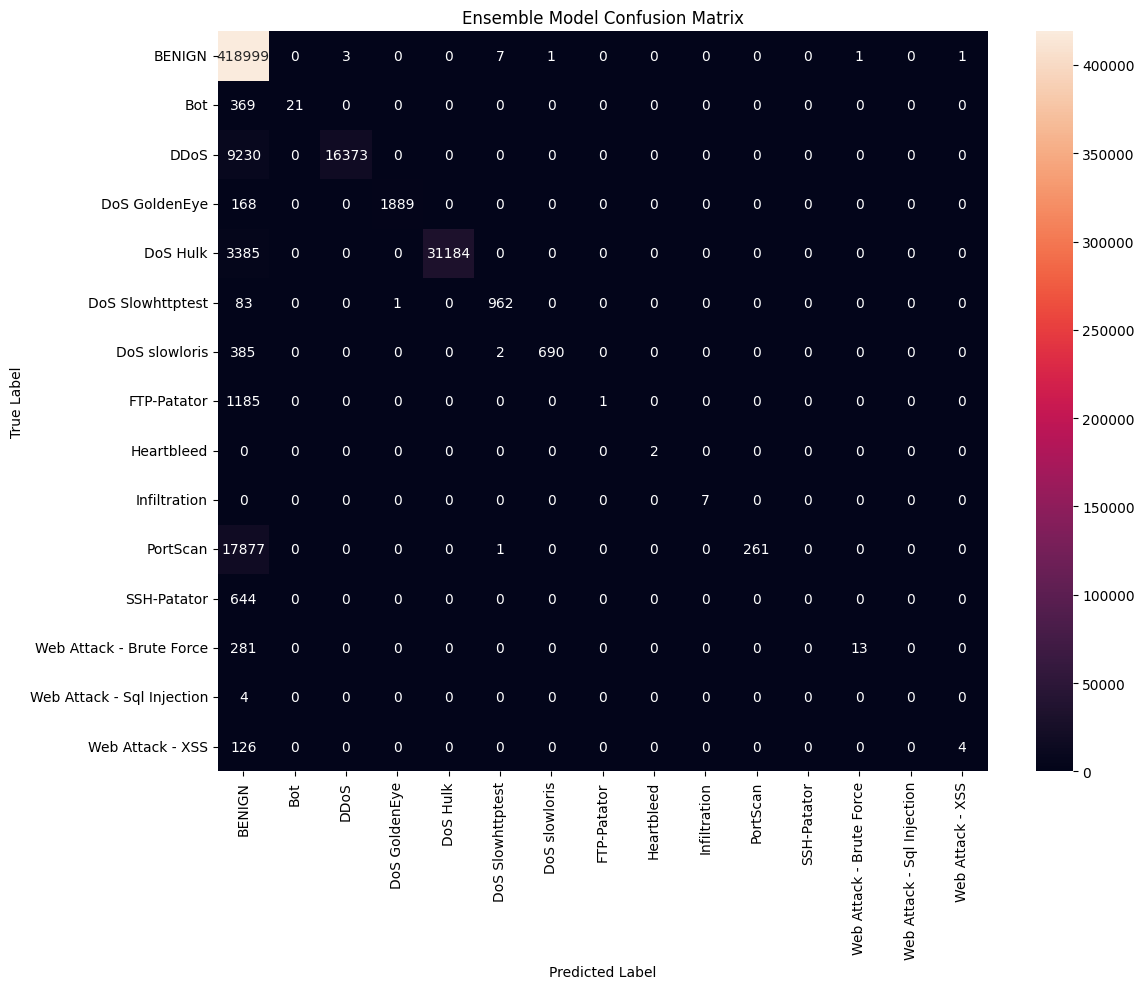

In [30]:
conf_matrix_ensemble = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_ensemble, annot=True, fmt='d', 
            xticklabels=network_dataset_encoder.classes_, 
            yticklabels=network_dataset_encoder.classes_)
plt.title('Ensemble Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/ensemble_confusion_matrix.png')

In [33]:

mlflow.set_experiment("network-anomaly-detector")

with mlflow.start_run(run_name="Ensemble_Model",):
    
    mlflow.log_metric("f1_macro", f1_score_macro_ensemble)
    mlflow.log_param("if_contamination", contamination)
    mlflow.log_param("if_n_estimators", network_dataset_iforest.n_estimators)
    mlflow.log_param("ensemble_strategy", "Rule-based if-else")
    mlflow.log_metric("recall", recall_score_ensemble)
    mlflow.log_metric("precision", precision_score_ensemble)
    mlflow.log_artifact("../reports/classification_report_ensemble.txt")
    mlflow.log_artifact("../reports/ensemble_confusion_matrix.png")
    mlflow.sklearn.log_model(network_dataset_ensemble, name="model")

2026/04/05 18:07:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## Summary — 05 Ensemble

A rule-based ensemble was constructed combining Isolation Forest and XGBoost into 
a two-stage pipeline. Isolation Forest acts as an anomaly gate; flagged flows are 
passed to XGBoost for specific attack classification.

| Model | Macro F1 |
|---|---|
| XGBoost (standalone) | 0.9036 |
| Isolation Forest (standalone) | 0.6822 |
| Ensemble | 0.5105 |

The ensemble underperforms XGBoost in isolation on labelled known attacks, which 
is the expected outcome. Its value lies in extending coverage to novel traffic 
patterns that fall outside the supervised model's training distribution.

The ensemble is implemented as an `EnsembleModel` class with a single `predict()` 
interface and logged to MLflow alongside its constituent models.